# ABIDES Declarative Configuration System — Tutorial

This notebook demonstrates the **declarative configuration system** for ABIDES market simulations.  
Instead of writing procedural `build_config()` functions, you can:

- Build simulations from **composable templates**
- **Enable/disable agent types** with a fluent API
- Set **per-agent computation delays**
- **Serialize** configs as YAML or JSON
- **Register custom agents** with the plugin registry
- Use the **AI discoverability API** for programmatic introspection

📖 Full reference: [`docs/reference/config-system.md`](../docs/reference/config-system.md)

In [1]:
import json
import tempfile
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

from abides_core import abides
from abides_core.utils import fmt_ts, ns_date, str_to_ns
import abides_markets.config_system as cfg
import abides_markets.config_system.agent_configs as acfg
from abides_markets.simulation import ResultProfile, run_simulation


---
## 1. Quick Start — Build, Compile, Run

The three-step workflow:
1. **Build** a `SimulationConfig` using the `SimulationBuilder`
2. **Compile** it into the runtime dict the `Kernel` expects
3. **Run** the simulation with `abides.run()`

> **Tip:** For most use-cases, prefer `run_simulation(config)` from
> `abides_markets.simulation` — it compiles a fresh runtime dict internally
> and returns a typed, immutable `SimulationResult`.  The manual
> `compile()` → `abides.run()` pattern shown here is the low-level path;
> each runtime dict is **consumed once** (agents accumulate state during the run).

In [2]:
# Build a config from the rmsc04 template
config = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .ticker("ABM")
    .seed(42)
    .build()
)

print(f"Ticker: {config.market.ticker}")
print(f"Date: {config.market.date}")
print(f"Trading hours: {config.market.start_time} — {config.market.end_time}")
print(f"Seed: {config.simulation.seed}")
print(f"Agent groups: {list(config.agents.keys())}")

Ticker: ABM
Date: 20210205
Trading hours: 09:30:00 — 10:00:00
Seed: 42
Agent groups: ['adaptive_market_maker', 'momentum', 'noise', 'value']


In [3]:
# Compile to a runtime dict
runtime = cfg.compile(config)

print(f"Runtime dict keys: {list(runtime.keys())}")
print(f"Total agents: {len(runtime['agents'])}")
print(f"Default computation delay: {runtime['default_computation_delay']} ns")

Runtime dict keys: ['seed', 'start_time', 'stop_time', 'agents', 'agent_latency_model', 'default_computation_delay', 'agent_computation_delays', 'oracle', 'random_state_kernel', 'stdout_log_level', 'event_sinks']
Total agents: 1117
Default computation delay: 50 ns


In [4]:
# Run the simulation
_, agents = abides.run(runtime)

print(f"Simulation completed. Agents in end_state: {len(agents)}")

[17772] INFO abides Simulation Start Time: 2026-05-23 19:41:14.475028
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 09:53:06, messages processed: 100,000, wallclock elapsed: 7.08s ---
[17772] INFO abides_markets.agents.market_makers.adaptive_market_maker_agent ADAPTIVE_POV_MARKET_MAKER_AGENT_1 flattened position: 633 shares of ABM at 2021-02-05 09:55:04
[17772] INFO abides_markets.agents.market_makers.adaptive_market_maker_agent ADAPTIVE_POV_MARKET_MAKER_AGENT_2 flattened position: 82 shares of ABM at 2021-02-05 09:56:34
[17772] INFO abides_core.engine.kernel Event Queue elapsed: 0:00:09.409376, messages: 133,903, messages per second: 14230.8
[17772] INFO abides_core.engine.kernel Simulation ending!
[17772] INFO abides Simulation End Time: 2026-05-23 19:41:24.248725
[17772] INFO abides Time taken to run simulation: 0:00:09.773697


Simulation completed. Agents in end_state: 1117


---
## 2. Templates — Composable Starting Points

Templates provide sensible defaults for common simulation scenarios.  
**Base templates** define a full configuration; **overlay templates** add agent groups on top.

In [5]:
# List all available templates
templates = cfg.list_templates()
for t in templates:
    overlay = " (overlay)" if t["is_overlay"] else ""
    print(f"  {t['name']}{overlay}: {t['description']}")

  rmsc04: Reference Market Simulation Configuration #4: 1 Exchange, 2 Market Makers, 102 Value Agents, 12 Momentum Agents, 1000 Noise Agents.
  liquid_market: High-liquidity full-day session (09:30-16:00). 100 Noise (120s), 30 Value (240s), 8 Momentum (120s), 1 Market Maker. Deep book with tight spreads from diverse agent participation.
  thin_market: Low-liquidity full-day session (09:30-16:00). 50 slow Noise (300s), 10 slow Value (600s), no market makers or momentum. Wide spreads and sporadic fills.
  with_momentum (overlay): Overlay: adds 12 Momentum agents.
  with_execution (overlay): Overlay: adds 1 POV Execution agent.
  stable_day: Low-volatility full-day session (09:30-16:00). Calm fundamental (fund_vol=3e-5, no megashocks), 1 market maker, 100 Noise (120s), 25 Value (300s). Use as a control scenario for strategy evaluation.
  volatile_day: High-volatility full-day session (09:30-16:00). fund_vol=2e-4 with ~1 megashock per session (interval=6h, mean 3000 cents). 100 Noise, 25 V

### Template stacking

You can stack multiple templates — later ones override earlier ones.  
Here we start with `rmsc04` and add a POV execution agent via the `with_execution` overlay:

In [6]:
config_stacked = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .apply_template("with_execution")  # adds a POV execution agent
    .seed(42)
    .build()
)

print("Agent groups after stacking:")
for name, group in config_stacked.agents.items():
    status = "enabled" if group.enabled else "disabled"
    print(f"  {name}: {group.count} agents ({status})")

Agent groups after stacking:
  adaptive_market_maker: 2 agents (enabled)
  momentum: 12 agents (enabled)
  noise: 1000 agents (enabled)
  pov_execution: 1 agents (enabled)
  value: 102 agents (enabled)


---
## 3. Builder API — Fine-Grained Control

The fluent builder lets you override any parameter:

In [7]:
config_custom = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .ticker("AAPL")
    .date("20220315")
    .end_time("11:00:00")
    .oracle(cfg.SparseMeanRevertingOracleConfig(r_bar=150_000))  # $1500.00 fundamental
    .exchange(cfg.ExchangeConfig(book_log_depth=20))
    .enable_agent(acfg.NoiseAgentConfig(), count=500)  # fewer noise agents
    .enable_agent(acfg.ValueAgentConfig(r_bar=150_000), count=50)
    .disable_agent(acfg.MomentumAgentConfig)  # no momentum agents
    # .disable_agent("momentum")  # no momentum agents - equivalent to above
    .computation_delay(100)  # global default: 100ns
    .seed(123)
    .log_orders(True)
    .build()
)

print(f"Ticker: {config_custom.market.ticker}")
print(f"Oracle r_bar: ${config_custom.market.oracle.r_bar / 100:.2f}")
print(f"Noise agents: {config_custom.agents['noise'].count}")
print(f"Value agents: {config_custom.agents['value'].count}")
print(f"Momentum enabled: {config_custom.agents['momentum'].enabled}")
print(f"Default computation delay: {config_custom.infrastructure.default_computation_delay} ns")

Ticker: AAPL
Oracle r_bar: $1500.00
Noise agents: 500
Value agents: 50
Momentum enabled: False
Default computation delay: 100 ns


---
## 4. Per-Agent Computation Delays

Different agent types can have different "thinking times".  
Market makers might be fast (low delay) while background noise agents are slow (high delay).  
The `computation_delay` parameter overrides the simulation-level default **per agent group**.

In [8]:
from collections import Counter

config_delays = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .computation_delay(50)  # global default
    .enable_agent(acfg.AdaptiveMarketMakerConfig(computation_delay=10), count=2)  # fast MM
    .enable_agent(acfg.NoiseAgentConfig(computation_delay=500), count=1000)  # slow noise
    .enable_agent(acfg.ValueAgentConfig(), count=102)  # uses global default (50ns)
    .seed(42)
    .build()
)

runtime_delays = cfg.compile(config_delays)

# Show the per-agent overrides
per_agent = runtime_delays.get("per_agent_computation_delays", {})
print(f"Global default: {runtime_delays['default_computation_delay']} ns")
print(f"Agents with custom delays: {len(per_agent)}")

# Summarize by agent type
delay_values = Counter(per_agent.values())
for delay, count in sorted(delay_values.items()):
    print(f"  {count} agents with {delay} ns delay")

Global default: 50 ns
Agents with custom delays: 0


You can also use the convenience method `agent_computation_delay()` on the builder:

In [9]:
# Equivalent: set computation delay for a specific agent type
config_alt = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .agent_computation_delay("noise", 500)
    .agent_computation_delay("adaptive_market_maker", 10)
    .seed(42)
    .build()
)

print(f"Noise delay: {config_alt.agents['noise'].params.get('computation_delay')} ns")
print(f"MM delay: {config_alt.agents['adaptive_market_maker'].params.get('computation_delay')} ns")

Noise delay: 500 ns
MM delay: 10 ns


---
## 5. Agent Registry — Discover & Extend

All built-in agent types are self-registered. You can discover them programmatically.

In [11]:
# List all registered agent types
agent_types = cfg.list_agent_types()

print(f"{'Name':<25} {'Category':<15} {'Description'}")
print("-" * 80)
for a in agent_types:
    print(f"{a['name']:<25} {a['category']:<15} {a.get('description', '')}")

Name                      Category        Description
--------------------------------------------------------------------------------
noise                     background      Simple agent that wakes once at a random time and places one random limit order at bid or ask.
value                     background      Bayesian learner that estimates fundamental value from noisy observations and trades when price deviates from estimate.
momentum                  strategy        Trend-follower using 20-bar vs 50-bar moving average crossover. Buys when MA(20) >= MA(50), sells otherwise.
mean_reversion            strategy        Contrarian agent using Bollinger-band / z-score mean reversion. Buys when price is unusually low, sells when unusually high.
adaptive_market_maker     market_maker    Market maker using inventory-skewed ladder strategy with adaptive spread. Places liquidity on both sides in multiple price levels.
pov_execution             execution       Percentage-of-volume execution ag

In [15]:
# Inspect parameters for a specific agent type
schema = cfg.registry.get_json_schema("value")
print("ValueAgent parameters:")
for name, prop in schema["properties"].items():
    desc = prop.get("description", "")
    default = prop.get("default", "—")
    print(f"  {name}: default={default}  ({desc})")

ValueAgent parameters:
  starting_cash: default=10000000  (Initial cash in cents ($100k = 10_000_000).)
  log_orders: default=None  (Override per-agent order logging. None = use simulation-level setting.)
  computation_delay: default=None  (Per-agent-type computation delay in nanoseconds. None = use the simulation-level default_computation_delay.)
  position_limit: default=None  (Per-symbol position limit (in shares). None = no limit.  Symmetric: allows [-N, +N].)
  position_limit_clamp: default=False  (When True, orders that would breach the position limit are reduced (clamped) instead of fully rejected.)
  max_drawdown: default=None  (Maximum loss from starting_cash in cents before the circuit breaker permanently halts the agent.  None = disabled.)
  max_order_rate: default=None  (Maximum orders per rate window before the circuit breaker permanently halts the agent.  None = disabled.)
  order_rate_window: default=1min  (Tumbling window duration for the order-rate circuit breaker as a

### Registering a custom agent

Third-party agents can be registered with `@register_agent` and used in configs just like built-in ones.  
The config model must extend `BaseAgentConfig` and implement `create_agents()`.

In [18]:
from pydantic import Field

_CUSTOM_DESC = "Custom noise agent with configurable threshold"


@cfg.register_agent("my_custom_noise", category="background", description=_CUSTOM_DESC)
class MyCustomNoiseConfig(acfg.BaseAgentConfig):
    """Custom noise agent that wraps the built-in NoiseAgent."""

    threshold: float = Field(default=0.05, description="Custom threshold.")

    def create_agents(self, count, id_start, master_rng, context):
        from abides_core.utils import get_wake_time, str_to_ns
        from abides_markets.agents import NoiseAgent

        log = self.log_orders if self.log_orders is not None else context.log_orders
        noise_mkt_open = context.mkt_open + str_to_ns("-00:30:00")
        date_ns = context.mkt_open - str_to_ns("09:30:00")
        noise_mkt_close = date_ns + str_to_ns("16:00:00")

        agents = []
        for j in range(id_start, id_start + count):
            rng = np.random.RandomState(
                seed=master_rng.randint(low=0, high=2**32, dtype="uint64")
            )
            agents.append(
                NoiseAgent(
                    id=j,
                    name=f"MyCustomNoise_{j}",
                    type="MyCustomNoiseAgent",
                    symbol=context.ticker,
                    starting_cash=self.starting_cash,
                    wakeup_time=get_wake_time(
                        noise_mkt_open, noise_mkt_close, rng
                    ),
                    log_orders=log,
                    random_state=rng,
                )
            )
        return agents


print("Custom agent registered!")
print(f"Registered types: {cfg.registry.registered_names()}")

Custom agent registered!
Registered types: ['adaptive_market_maker', 'impact_order', 'mean_reversion', 'momentum', 'my_custom_noise', 'noise', 'pov_execution', 'twap_execution', 'value', 'vwap_execution']


In [19]:
# Use the custom agent in a simulation
config_custom_agent = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .enable_agent(MyCustomNoiseConfig(threshold=0.1), count=10)
    .seed(42)
    .build()
)

runtime_custom = cfg.compile(config_custom_agent)
print(f"Total agents (rmsc04 + 10 custom): {len(runtime_custom['agents'])}")


Total agents (rmsc04 + 10 custom): 1127


---
## 6. Serialization — YAML & JSON

Configs can be saved to YAML or JSON and loaded back. This is useful for:
- Sharing experiment configurations
- Version-controlling simulation setups
- Parameter sweeps from config files

In [20]:
# Save to YAML
config_to_save = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .ticker("AAPL")
    .enable_agent(acfg.NoiseAgentConfig(computation_delay=200), count=500)
    .seed(42)
    .build()
)

yaml_path = Path(tempfile.gettempdir()) / "abides_config_demo.yaml"
cfg.save_config(config_to_save, yaml_path)

# Display the YAML content
print(yaml_path.read_text())

market:
  ticker: AAPL
  date: '20210205'
  start_time: 09:30:00
  end_time: '10:00:00'
  oracle:
    type: sparse_mean_reverting
    r_bar: 100000
    mean_reversion_half_life: 48d
    sigma_s: 0.0
    fund_vol: 5.0e-05
    megashock_mean_interval: 100000h
    kappa: null
    megashock_lambda_a: null
    megashock_mean: 1000.0
    megashock_var: 50000.0
  opening_price: null
  exchange:
    book_logging: true
    book_log_depth: 10
    book_capture: null
    stream_history_length: 500
    log_orders: false
    pipeline_delay: 0
    computation_delay: 0
agents:
  adaptive_market_maker:
    enabled: true
    count: 2
    params:
      pov: 0.025
      min_order_size: 1
      window_size: adaptive
      num_ticks: 10
      wake_up_freq: 60s
      skew_beta: 0
      price_skew_param: 4
      level_spacing: 5
      spread_alpha: 0.75
      backstop_quantity: 0
      cancel_limit_delay: 50
  momentum:
    enabled: true
    count: 12
    params:
      min_size: 1
      max_size: 10
      wak

In [21]:
# Load it back and verify
loaded = cfg.load_config(yaml_path)

print(f"Loaded ticker: {loaded.market.ticker}")
print(f"Loaded noise agent count: {loaded.agents['noise'].count}")
print(f"Loaded noise computation_delay: {loaded.agents['noise'].params.get('computation_delay')}")
print(f"Loaded seed: {loaded.simulation.seed}")

Loaded ticker: AAPL
Loaded noise agent count: 500
Loaded noise computation_delay: 200
Loaded seed: 42


In [22]:
# JSON works too
json_path = Path(tempfile.gettempdir()) / "abides_config_demo.json"
cfg.save_config(config_to_save, json_path)

d = cfg.config_to_dict(config_to_save)
print(json.dumps(d, indent=2)[:500], "...")

{
  "market": {
    "ticker": "AAPL",
    "date": "20210205",
    "start_time": "09:30:00",
    "end_time": "10:00:00",
    "oracle": {
      "type": "sparse_mean_reverting",
      "r_bar": 100000,
      "mean_reversion_half_life": "48d",
      "sigma_s": 0.0,
      "fund_vol": 5e-05,
      "megashock_mean_interval": "100000h",
      "kappa": null,
      "megashock_lambda_a": null,
      "megashock_mean": 1000.0,
      "megashock_var": 50000.0
    },
    "opening_price": null,
    "exchange": {
 ...


---
## 7. AI Discoverability API

The config system exposes structured introspection functions.  
These are designed for LLM tool-calling but also useful interactively.

In [23]:
# Full JSON Schema for the config structure
schema = cfg.get_config_schema()
print(f"Top-level config sections: {list(schema['properties'].keys())}")
print(f"Schema keys: {list(schema.keys())}")

Top-level config sections: ['market', 'agents', 'infrastructure', 'simulation']
Schema keys: ['$defs', 'description', 'properties', 'required', 'title', 'type']


In [24]:
# Full manifest — designed for auto-generating a config UI or LLM tool-calling
manifest = cfg.get_full_manifest()
print(f"Manifest keys: {list(manifest.keys())}")
print(f"Oracle options: {[o['type'] for o in manifest['oracle_options']]}")
print(f"Categories: {list(manifest['categories'].keys())}")
print(f"Templates: {[t['name'] for t in manifest['templates']]}")


Manifest keys: ['agent_types', 'market_config_schema', 'oracle_options', 'templates', 'categories']
Oracle options: ['sparse_mean_reverting', 'mean_reverting', None]
Categories: ['background', 'market_maker', 'strategy', 'execution']
Templates: ['rmsc04', 'liquid_market', 'thin_market', 'with_momentum', 'with_execution', 'stable_day', 'volatile_day', 'low_liquidity', 'trending_day', 'stress_test']


In [25]:
# Validate a config dict — returns a structured ValidationResult
valid_result = cfg.validate_config({"simulation": {"seed": 42}})
print("Valid config:", valid_result.valid)

invalid_result = cfg.validate_config({"agents": {"noise": {"count": -1}}})
print("Invalid config:", invalid_result.valid)
for issue in invalid_result.errors:
    print(f"  [{issue.severity}] {issue.field_path}: {issue.message}")


Valid config: False
Invalid config: False
  [error] (root): 2 validation errors for SimulationConfig
market
  Field required [type=missing, input_value={'agents': {'noise': {'count': -1}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
agents.noise.count
  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-1, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/greater_than_equal


---
## 8. Running a Simulation and Extracting Results

`run_simulation()` compiles a fresh runtime dict internally and returns a typed,
immutable `SimulationResult`. Use `ResultProfile` to control extraction depth:

| Profile | What's included |
|---------|----------------|
| `SUMMARY` (default) | Metadata, per-agent PnL, liquidity metrics |
| `QUANT` | + L1/L2 time-series as numpy arrays, trade attribution, equity curves |
| `FULL` | + raw agent event log DataFrame |

For direct Kernel access (custom sinks, gymnasium environments), the low-level
`compile()` → `abides.run()` path is described in
[`docs/reference/data-extraction.md`](../docs/reference/data-extraction.md).


In [30]:
# Build and run — QUANT profile adds L1/L2 time-series to the result
sim_config = (
    cfg.SimulationBuilder()
    .apply_template("rmsc04")
    .end_time("10:30:00")  # 1 hour of trading
    .seed(42)
    .build()
)

result = run_simulation(sim_config, profile=ResultProfile.QUANT)
print(result.summary())


[17772] INFO abides Simulation Start Time: 2026-05-23 19:45:46.881166
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 09:53:10, messages processed: 100,000, wallclock elapsed: 5.95s ---
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 10:12:31, messages processed: 200,000, wallclock elapsed: 12.77s ---
[17772] INFO abides_markets.agents.market_makers.adaptive_market_maker_agent ADAPTIVE_POV_MARKET_MAKER_AGENT_2 flattened position: 412 shares of ABM at 2021-02-05 10:25:15
[17772] INFO abides_markets.agents.market_makers.adaptive_market_maker_agent ADAPTIVE_POV_MARKET_MAKER_AGENT_1 flattened position: 1241 shares of ABM at 2021-02-05 10:25:21
[17772] INFO abides_core.engine.kernel --- Simulation time: 2021-02-05 10:28:54, messages processed: 300,000, wallclock elapsed: 19.21s ---
[17772] INFO abides_core.engine.k

Simulation | seed=42 | tickers=ABM | elapsed=19.60s
  ABM: last=$1000.71 vwap=$1000.31 close_bid=$1000.65 close_ask=$1000.71 vol=2,352,116 no_bid=1.0% no_ask=0.9%
  Top agents by PnL:
    [2] AdaptivePOVMarketMakerAgent: MtM=$122266.25 PnL=+$22266.25 (+22.27%)
    [1] AdaptivePOVMarketMakerAgent: MtM=$115902.27 PnL=+$15902.27 (+15.90%)
    [904] NoiseAgent: MtM=$105297.47 PnL=+$5297.47 (+5.30%)
    [39] NoiseAgent: MtM=$102806.24 PnL=+$2806.24 (+2.81%)
    [356] NoiseAgent: MtM=$102507.38 PnL=+$2507.38 (+2.51%)
  Profile: METADATA, AGENT_PNL, LIQUIDITY, L1_SERIES, L2_SERIES, TRADE_ATTRIBUTION, EQUITY_CURVE
  (Agent logs not extracted — re-run with ResultProfile.FULL)


L1 snapshots: 60363 rows, columns: ['time_ns', 'bid_price_cents', 'bid_qty', 'ask_price_cents', 'ask_qty']


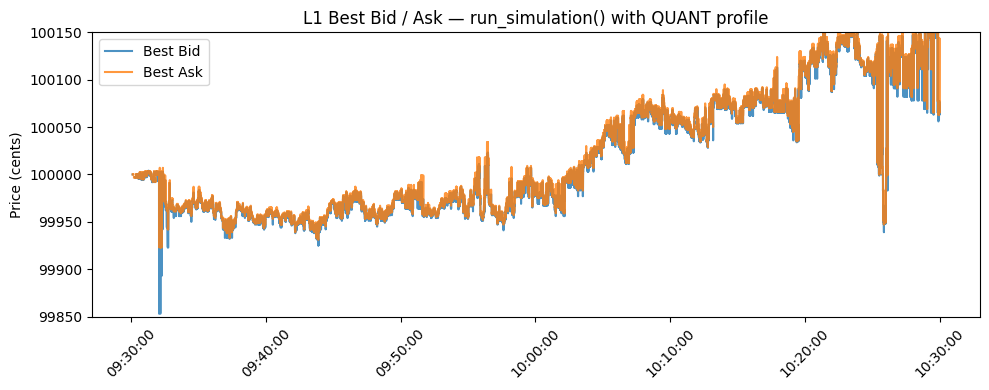

In [32]:
# Extract L1 time-series from the result (available because QUANT profile was used)
l1_df = result.markets["ABM"].l1_series.as_dataframe()
print(f"L1 snapshots: {len(l1_df)} rows, columns: {list(l1_df.columns)}")

# Convert timestamps to nanoseconds-from-midnight for plotting
l1_df["t"] = l1_df["time_ns"].apply(lambda x: x - ns_date(int(x)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(l1_df["t"], l1_df["bid_price_cents"].astype(float), label="Best Bid", alpha=0.8)
ax.plot(l1_df["t"], l1_df["ask_price_cents"].astype(float), label="Best Ask", alpha=0.8)

band = 150
ax.set_ylim(100_000 - band, 100_000 + band)
ax.set_ylabel("Price (cents)")
ax.set_title("L1 Best Bid / Ask — run_simulation() with QUANT profile")
ax.legend()

time_mesh = np.arange(str_to_ns("09:30:00"), str_to_ns("10:40:00"), 1e9 * 60 * 10)
ax.set_xticks(time_mesh)
ax.set_xticklabels([fmt_ts(int(t)).split(" ")[1] for t in time_mesh], rotation=45)
plt.tight_layout()
plt.show()


---
## 9. Comparing Declarative vs. Procedural Config

The new system produces the exact same runtime dict as `rmsc04.build_config()`.  
Both approaches are fully supported — use whichever fits your workflow.

In [33]:
from collections import Counter

from abides_markets.configs import rmsc04

# Legacy procedural approach
old_config = rmsc04.build_config(seed=42)
old_types = Counter(type(a).__name__ for a in old_config["agents"])

# Declarative approach
new_config = cfg.SimulationBuilder().apply_template("rmsc04").seed(42).build()
new_runtime = cfg.compile(new_config)
new_types = Counter(type(a).__name__ for a in new_runtime["agents"])

print(f"Procedural agent count: {len(old_config['agents'])}")
print(f"Declarative agent count: {len(new_runtime['agents'])}")
print(f"Agent types match: {old_types == new_types}")
print(f"Runtime dict keys match: {set(old_config.keys()).issubset(set(new_runtime.keys()))}")
print()
print("Agent composition:")
for agent_type, count in sorted(new_types.items()):
    print(f"  {agent_type}: {count}")

Procedural agent count: 1117
Declarative agent count: 1117
Agent types match: True
Runtime dict keys match: True

Agent composition:
  AdaptiveMarketMakerAgent: 2
  ExchangeAgent: 1
  MomentumAgent: 12
  NoiseAgent: 1000
  ValueAgent: 102


---
## 10. Summary

| Feature | How |
|---------|-----|
| Start from template | `SimulationBuilder().apply_template("rmsc04")` |
| Override market params | `.ticker("AAPL").date("20220315")` |
| Enable/disable agents | `.enable_agent(NoiseAgentConfig(), count=500)` / `.disable_agent("momentum")` |
| Per-agent delays | `.enable_agent(NoiseAgentConfig(computation_delay=200), count=500)` |
| Stack templates | `.apply_template("rmsc04").apply_template("with_execution")` |
| Serialize to YAML | `save_config(config, "sim.yaml")` |
| Register custom agent | `@register_agent("my_agent", category="strategy")` |
| AI introspection | `list_agent_types()`, `get_config_schema()`, `get_full_manifest()` |
| Structured validation | `validate_config(d)` → `ValidationResult` (`.valid`, `.errors`, `.to_dict()`) |
| Run (recommended) | `run_simulation(config, profile=ResultProfile.QUANT)` → `SimulationResult` |
| Run (low-level) | `runtime = compile(config); abides.run(runtime)` |
